# This task performs an NDVI prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [97]:
# Read data
ndvi_df = pd.read_csv('dataset/ndvi_prediction/monthly_ndvi_weather_2017_2024.csv')

ndvi_df.head(10)

# ndvi_df = ndvi_df[(ndvi_df['Month'] >=4) & (ndvi_df['Month'] <=10)]
# ndvi_df.head(10)

,Year,Month,NDVI,Precipitation (mm),Specific Humidity (g/kg),Avg. Temp (C),Min Temp (C),Max Temp (C),Surface Pressure (kPa),Wind Speed (m/s),Relative Humidity (%),Dew Point (C),Cloud Amount
0,2017,1,0.074462,44.53,2.856129,-3.808710,-13.95,2.87,97.338387,2.950968,94.858387,-4.700645,0.598781
1,2017,2,0.363243,58.09,4.484643,2.467500,-3.02,9.83,96.763571,3.407500,93.209643,1.513929,0.776768
2,2017,3,0.587939,52.41,5.312258,6.326774,-1.68,18.25,96.825161,3.351613,85.711290,3.924194,0.702245
3,2017,4,0.460918,13.32,4.828333,6.524333,-3.38,19.01,97.221333,2.398000,77.963000,2.579667,0.548267
4,2017,5,0.680700,52.99,7.751935,13.457742,0.37,28.16,96.923548,2.230323,77.588710,9.223548,0.635777
5,2017,6,0.632814,52.39,8.609333,17.951667,7.24,31.62,96.746000,2.721000,66.730000,10.997000,0.571973
6,2017,7,0.660173,95.15,9.174194,18.603871,7.22,31.88,96.782258,2.702903,68.797742,11.974516,0.703771
7,2017,8,0.668001,84.34,9.359032,17.213548,7.92,28.97,97.007742,2.124516,75.047097,12.300968,0.663658
8,2017,9,0.636755,81.21,7.371000,12.324667,3.81,22.35,96.769000,2.452667,80.522333,8.780667,0.698630
9,2017,10,0.566424,37.97,7.030968,9.965484,0.26,21.00,97.219032,3.058710,87.972903,8.071290,0.648961


In [98]:
ndvi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      96 non-null     int64  
 1   Month                     96 non-null     int64  
 2   NDVI                      96 non-null     float64
 3   Precipitation (mm)        96 non-null     float64
 4   Specific Humidity (g/kg)  96 non-null     float64
 5   Avg. Temp (C)             96 non-null     float64
 6   Min Temp (C)              96 non-null     float64
 7   Max Temp (C)              96 non-null     float64
 8   Surface Pressure (kPa)    96 non-null     float64
 9   Wind Speed (m/s)          96 non-null     float64
 10  Relative Humidity (%)     96 non-null     float64
 11  Dew Point (C)             96 non-null     float64
 12  Cloud Amount              96 non-null     float64
dtypes: float64(11), int64(2)
memory usage: 9.9 KB


In [99]:
ndvi_df.describe()

,Year,Month,NDVI,Precipitation (mm),Specific Humidity (g/kg),Avg. Temp (C),Min Temp (C),Max Temp (C),Surface Pressure (kPa),Wind Speed (m/s),Relative Humidity (%),Dew Point (C),Cloud Amount
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,2020.500000,6.500000,0.429320,70.569375,6.539202,9.503526,-0.202917,20.406667,96.810176,2.952677,82.884655,6.211419,0.125868
std,2.303316,3.470174,0.182743,35.004134,2.026273,6.638480,5.951404,8.568139,0.386653,0.687074,11.406126,4.642205,2.386750
min,2017.000000,1.000000,0.044754,13.320000,2.856129,-3.808710,-14.190000,2.870000,95.569032,1.833333,52.601935,-4.700645,-9.990000
25%,2018.750000,3.750000,0.323710,44.497500,4.708548,3.657613,-4.112500,12.802500,96.614833,2.403500,77.183145,2.010161,0.576714
50%,2020.500000,6.500000,0.425746,67.965000,6.317581,9.042581,-1.650000,20.315000,96.834677,2.818536,84.773371,6.240102,0.664252
75%,2022.250000,9.250000,0.575185,93.827500,8.377016,15.630610,4.872500,27.612500,97.018194,3.350887,93.004661,10.402903,0.776398
max,2024.000000,12.000000,0.746139,195.530000,11.332258,21.397419,10.030000,38.620000,97.783214,5.498276,96.970645,15.113226,0.900535


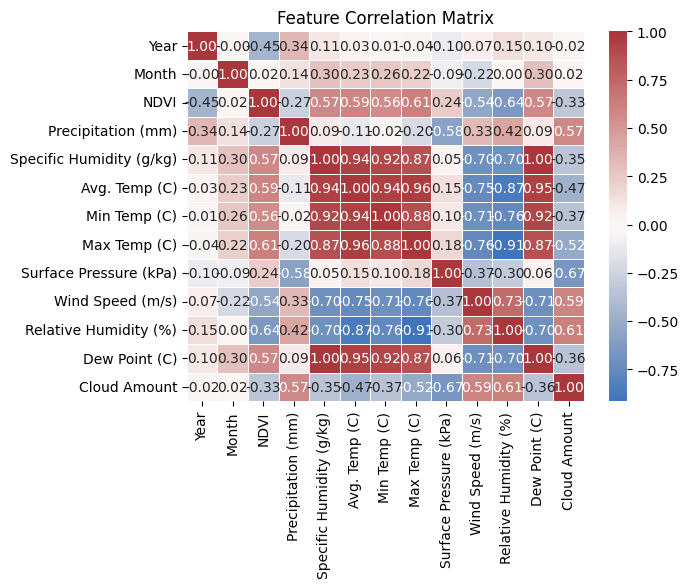

In [122]:
# Correlation Matrix
from sklearn.preprocessing import LabelEncoder
df1 = ndvi_df.copy()

label_encoder = LabelEncoder()

for col in df1:
    df1[col] = label_encoder.fit_transform(df1[col])
    
cm = sns.heatmap(
    df1.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=.5
)
plt.title("Feature Correlation Matrix")
plt.show()

# Data Processing

In [195]:
from sklearn.model_selection import train_test_split

# Split into X, y
y = ndvi_df['NDVI']
# X = ndvi_df.drop(columns=['Month', 'NDVI', 'Precipitation (mm)', 'Cloud Amount'])
X = ndvi_df.drop(columns=['NDVI', 'Relative Humidity (%)', 'Avg. Temp (C)', 'Wind Speed (m/s)'])
X = pd.get_dummies(X)

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

print(np.shape(y))
print(np.shape(X))
print(y_test)

(96,)
(96, 9)
40    0.718758
31    0.648467
46    0.425760
59    0.072257
78    0.364265
74    0.245078
65    0.443354
44    0.444322
80    0.419932
85    0.056618
Name: NDVI, dtype: float64


# Machine Learning Models

In [196]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model    import LinearRegression, BayesianRidge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.neighbors       import KNeighborsRegressor
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Define models
models = [
    ("Linear Regression",    LinearRegression()),
    ("Decision Tree",        DecisionTreeRegressor(random_state=1)),
    ("Random Forest",        RandomForestRegressor(random_state=1)),
    ("Gradient Boosting",    GradientBoostingRegressor(random_state=1)),
    ("XGBoost",              XGBRegressor(random_state=1)),
    ("LightGBM",             LGBMRegressor(random_state=1, verbosity=-1)),
    ("KNN",                  KNeighborsRegressor(n_neighbors=4)),
    ("Bayesian Ridge",       BayesianRidge()),
]

In [197]:
results = []
for name, model in models:
    print(f">>> Training & evaluating: {name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    results.append((name, mse, r2))

summary = pd.DataFrame(results, columns = ['Model', 'MSE', 'R2'])
summary

>>> Training & evaluating: Linear Regression
>>> Training & evaluating: Decision Tree
>>> Training & evaluating: Random Forest
>>> Training & evaluating: Gradient Boosting
>>> Training & evaluating: XGBoost
>>> Training & evaluating: LightGBM
>>> Training & evaluating: KNN
>>> Training & evaluating: Bayesian Ridge


,Model,MSE,R2
0,Linear Regression,0.013005,0.687579
1,Decision Tree,0.009585,0.769720
2,Random Forest,0.010578,0.745867
3,Gradient Boosting,0.007418,0.821802
4,XGBoost,0.004924,0.881715
5,LightGBM,0.010263,0.753451
6,KNN,0.029974,0.279914
7,Bayesian Ridge,0.015829,0.619716


XGBoost provides the best performance (MSE ≈ 0.0049 and R2 ≈ 0.88), followed by Gradient Boosting (MSE ≈ 0.0074 and R2 ≈ 0.82) and Decision Tree (MSE ≈ 0.0096 and R2 ≈ 0.77).

# Predict NDVI for 2000-2016

In [204]:
weather_data = pd.read_csv('dataset/weather/monthly_weather_data.csv')
weather_data = weather_data[(weather_data['Year'] >= 2000) & (weather_data['Year'] <= 2016)]
weather_data = weather_data.drop(columns=['Relative Humidity (%)', 'Avg. Temp (C)', 'Wind Speed (m/s)'])

weather_data.tail()

,Year,Month,Precipitation (mm),Specific Humidity (g/kg),Min Temp (C),Max Temp (C),Surface Pressure (kPa),Dew Point (C),Cloud Amount
199,2016,8,42.59,9.843226,4.89,30.93,97.225806,13.090323,0.477216
200,2016,9,23.03,8.520333,6.04,28.72,97.137333,10.890000,0.477647
201,2016,10,56.30,5.893226,2.01,16.95,97.267742,5.578065,0.712268
202,2016,11,71.89,4.774333,-4.82,14.23,96.670000,2.190333,0.796583
203,2016,12,17.78,3.950323,-6.29,7.76,98.028387,0.029677,0.615345


In [208]:
name_best, model_best = models[4][0], models[4][1]

print(f">>> Training & evaluating: {name_best}")
model_best.fit(x_train, y_train)
y_pred = model_best.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE: {mse}", f"R2: {r2}")

>>> Training & evaluating: XGBoost
MSE: 0.004923650566977541 R2: 0.8817149222909316


In [210]:
# Predict NDVI for 2000-2016
ndvi = model_best.predict(weather_data)
print(ndvi[:5])

[0.23856284 0.37395337 0.38105953 0.53241163 0.6847099 ]


In [218]:
d = {'Year': weather_data['Year'].values, 'Month': weather_data['Month'].values, 'NDVI': ndvi}
ndvi_predict = pd.DataFrame(data=d)
ndvi_predict.to_csv('dataset/ndvi/monthly_ndvi_predict_2000_2016.csv', index=False)
ndvi_predict

,Year,Month,NDVI
0,2000,1,0.238563
1,2000,2,0.373953
2,2000,3,0.381060
3,2000,4,0.532412
4,2000,5,0.684710
...,...,...,...
199,2016,8,0.573725
200,2016,9,0.600731
201,2016,10,0.524158
202,2016,11,0.381971


In [221]:
ndvi_data = pd.read_csv('dataset/ndvi/monthly_median_ndvi_2017_2024.csv')
ndvi_data.rename(columns={'Median': "NDVI"}, inplace=True)
ndvi_full = pd.concat([ndvi_predict, ndvi_data])
ndvi_full.to_csv('dataset/ndvi/monthly_ndvi_2000_2024.csv', index=False)
ndvi_full

,Year,Month,NDVI
0,2000,1,0.238563
1,2000,2,0.373953
2,2000,3,0.381060
3,2000,4,0.532412
4,2000,5,0.684710
...,...,...,...
91,2024,8,0.423838
92,2024,9,0.394554
93,2024,10,0.328136
94,2024,11,0.201173


# Aggregate annual data after performing NDVI prediction

In [235]:
# Process NDVI data
ndvi_data = pd.read_csv('dataset/ndvi/monthly_ndvi_2000_2024.csv')
ndvi_data = ndvi_data.groupby('Year')['NDVI'].agg([
    ('NDVI_season_mean', 'mean'),
    ('NDVI_season_max', 'max'),
    ('NDVI_season_sum', 'sum')
]).reset_index()
ndvi_data = ndvi_data[ndvi_data['Year'] < 2023]
ndvi_data

,Year,NDVI_season_mean,NDVI_season_max,NDVI_season_sum
0,2000,0.488564,0.684710,5.862769
1,2001,0.476240,0.669287,5.714881
2,2002,0.516070,0.685655,6.192841
3,2003,0.490469,0.686494,5.885627
4,2004,0.488999,0.684509,5.867992
5,2005,0.527623,0.689724,6.331479
6,2006,0.503270,0.685987,6.039237
7,2007,0.497174,0.645557,5.966088
8,2008,0.473921,0.686786,5.687048
9,2009,0.481703,0.692027,5.780438


In [227]:
# Weather data
weather_data = pd.read_csv('dataset/weather/monthly_weather_data.csv')

rename_map = {
    'Precipitation (mm)'        : 'Precipitation',
    'Specific Humidity (g/kg)'  : 'Specific Humidity',
    'Avg. Temp (C)'             : 'Avg. Temp',
    'Min Temp (C)'              : 'Min Temp',
    'Max Temp (C)'              : 'Max Temp',
    'Surface Pressure (kPa)'    : 'Surface Pressure',
    'Wind Speed (m/s)'          : 'Wind Speed',
    'Relative Humidity (%)'     : 'Relative Humidity',
    'Dew Point (C)'             : 'Dew Point',
}
weather_data.rename(columns=rename_map, inplace=True)

# Annual weather
agg_map = {
    'Precipitation'     : 'sum',
    'Specific Humidity' : 'mean',
    'Avg. Temp'         : 'mean',
    'Min Temp'          : 'min',
    'Max Temp'          : 'max',
    'Surface Pressure'  : 'mean',
    'Wind Speed'        : 'mean',
    'Relative Humidity' : 'mean',
    'Dew Point'         : 'mean',
    'Cloud Amount'      : 'mean',
}

weather_grouped = weather_data.groupby('Year').agg(agg_map).reset_index()
weather_grouped = weather_grouped[weather_grouped['Year'] < 2023]

weather_grouped

,Year,Precipitation,Specific Humidity,Avg. Temp,Min Temp,Max Temp,Surface Pressure,Wind Speed,Relative Humidity,Dew Point,Cloud Amount
0,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564
1,2001,1045.30,6.355228,8.103744,-14.68,31.77,96.778001,3.026177,86.802500,5.731251,0.717972
2,2002,996.03,6.395150,8.605842,-16.58,30.20,96.764080,3.123091,85.180753,5.881475,0.717846
3,2003,727.68,6.070564,8.487295,-15.75,36.89,96.962748,2.821777,81.450688,4.825740,0.615799
4,2004,795.96,6.067934,7.908168,-10.62,29.29,96.835748,2.986987,84.540502,5.075075,0.711226
5,2005,721.47,6.220906,8.401478,-15.51,29.44,96.943833,2.861204,83.695482,5.343078,0.688108
6,2006,813.39,6.540325,8.772931,-10.41,33.67,96.876671,2.981709,84.768268,5.923098,0.699514
7,2007,1022.95,6.611201,8.818974,-7.95,26.74,96.874842,3.148360,86.614580,6.473875,0.684323
8,2008,915.80,6.373743,8.095081,-7.88,28.00,96.763982,2.961533,86.733460,5.770962,0.724181
9,2009,909.01,6.336496,8.246400,-14.17,30.55,96.677208,2.908163,85.245785,5.561077,0.690161


In [229]:
# Yield data
yield_data = pd.read_csv('dataset/yield/yield.csv')
yield_data = yield_data[(yield_data['Area']=='Luxembourg')]
yield_data = yield_data[yield_data['Year']<2023]
yield_data.rename(columns={'Value': 'Yield'}, inplace=True)
yield_data = yield_data[['Year', 'Item', 'Yield']].sort_values(by=['Year', 'Item'])
yield_data = yield_data[yield_data['Item'].isin(['Apples', 'Grapes', 'Maize (corn)', 'Potatoes', 'Wheat'])]
yield_data

,Year,Item,Yield
5690,2000,Apples,11284.2
5732,2000,Grapes,14023.7
5756,2000,Maize (corn),8000.0
5780,2000,Potatoes,33604.3
5804,2000,Wheat,5576.9
...,...,...,...
5712,2022,Apples,13800.0
5754,2022,Grapes,9680.3
5778,2022,Maize (corn),5055.6
5802,2022,Potatoes,22828.1


In [234]:
# Pesticides data
pesticides_data = pd.read_csv('dataset/yield/pesticides.csv')
pesticides_data = pesticides_data[['Year', 'Value']]
pesticides_data.rename(columns={'Value': 'Pesticides'}, inplace=True)
pesticides_data

,Year,Pesticides
0,2000,2.45
1,2001,2.45
2,2002,2.45
3,2003,2.45
4,2004,2.45
5,2005,2.49
6,2006,2.49
7,2007,2.45
8,2008,2.41
9,2009,2.44


In [236]:
# Merge data
final_data = pd.merge(weather_grouped, pesticides_data, on='Year', how='inner').merge(ndvi_data, on='Year', how='inner').merge(yield_data, on='Year', how='inner')
final_data.to_csv('dataset/final_data.csv', index=False)
final_data

,Year,Precipitation,Specific Humidity,Avg. Temp,Min Temp,Max Temp,Surface Pressure,Wind Speed,Relative Humidity,Dew Point,Cloud Amount,Pesticides,NDVI_season_mean,NDVI_season_max,NDVI_season_sum,Item,Yield
0,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Apples,11284.2
1,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Grapes,14023.7
2,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Maize (corn),8000.0
3,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Potatoes,33604.3
4,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Wheat,5576.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Apples,13800.0
111,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Grapes,9680.3
112,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Maize (corn),5055.6
113,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Potatoes,22828.1
